In [2]:
# Import all dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, explained_variance_score

# Section 1:
## The dataset

**Source**:

Wang,Q.; Ahmad,W.; Ahmad, A.;Aslam, F.;Mohamed,A.; Vatin,N.I. Application of Soft Computing Techniques to Predict the Strength of Geopolymer Composites. Polymers 2022, 14, 1074. [https://doi.org/10.3390/polym14061074]

*Supplementary files:* [link](https://www.mdpi.com/article/10.3390/polym14061074/s1)

In [4]:
dataset_path = "GPC_wangetal.csv"

#Basic Description of the dataset
FA_geoPC = pd.read_csv(dataset_path)
print(FA_geoPC.head)
FA_geoPC.describe().T

<bound method NDFrame.head of      Fly ash   GGBS   Na2SiO3  NaOH  Fine aggregate  Gravel 4/10 mm   \
0       391.0    0.0     92.0  75.0           721.0            450.0   
1       380.0    0.0     89.0  73.0           721.0            450.0   
2       371.0    0.0     87.0  72.0           721.0            450.0   
3       367.0    0.0     86.0  71.0           742.0            464.0   
4       357.0    0.0     84.0  69.0           742.0            464.0   
..        ...    ...      ...   ...             ...              ...   
358       0.0  300.0     18.0  12.0           757.0            227.0   
359       0.0  350.0     21.0  14.0           703.0            211.0   
360       0.0  400.0     24.0  16.0           649.0            195.0   
361       0.0  400.0     28.0  16.0           649.0            195.0   
362       0.0  450.0     27.0  18.0           595.0            178.0   

     Gravel 10/20 mm  Water/solids ratio  NaOH Molarity  Compressive Strength  \
0              661.0    

,count,mean,std,min,25%,50%,75%,max
Fly ash,363.0,174.341708,167.948596,0.0,0.00,120.00,340.0000,523.00
GGBS,363.0,225.146143,162.267745,0.0,65.00,300.00,360.0000,450.00
Na2SiO3,363.0,111.660275,48.159112,18.0,84.00,108.00,129.4300,342.00
NaOH,363.0,53.743140,31.911119,3.5,24.81,56.00,72.0000,147.00
Fine aggregate,363.0,729.883719,130.969916,459.0,651.00,728.00,790.1500,1360.00
Gravel 4/10 mm,363.0,288.386446,372.307421,0.0,0.00,208.00,449.5200,1293.40
Gravel 10/20 mm,359.0,745.584763,351.928640,0.0,582.40,800.00,991.0000,1298.00
Water/solids ratio,362.0,0.343564,0.113960,0.0,0.26,0.34,0.4175,0.63
NaOH Molarity,363.0,8.140799,4.564865,1.0,4.00,9.20,12.0000,20.00
Compressive Strength,363.0,43.279339,17.873939,8.0,29.95,42.10,56.0000,86.08


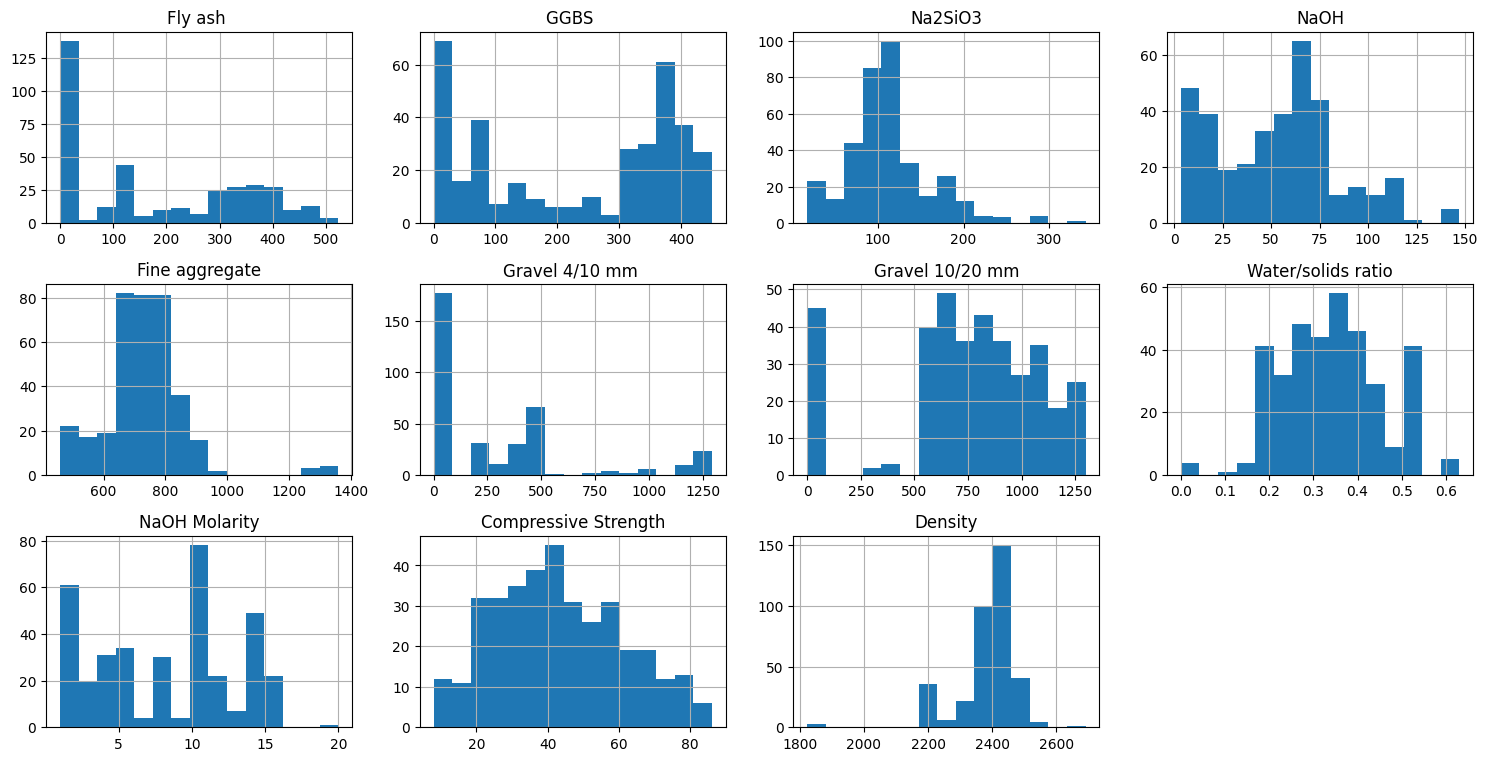

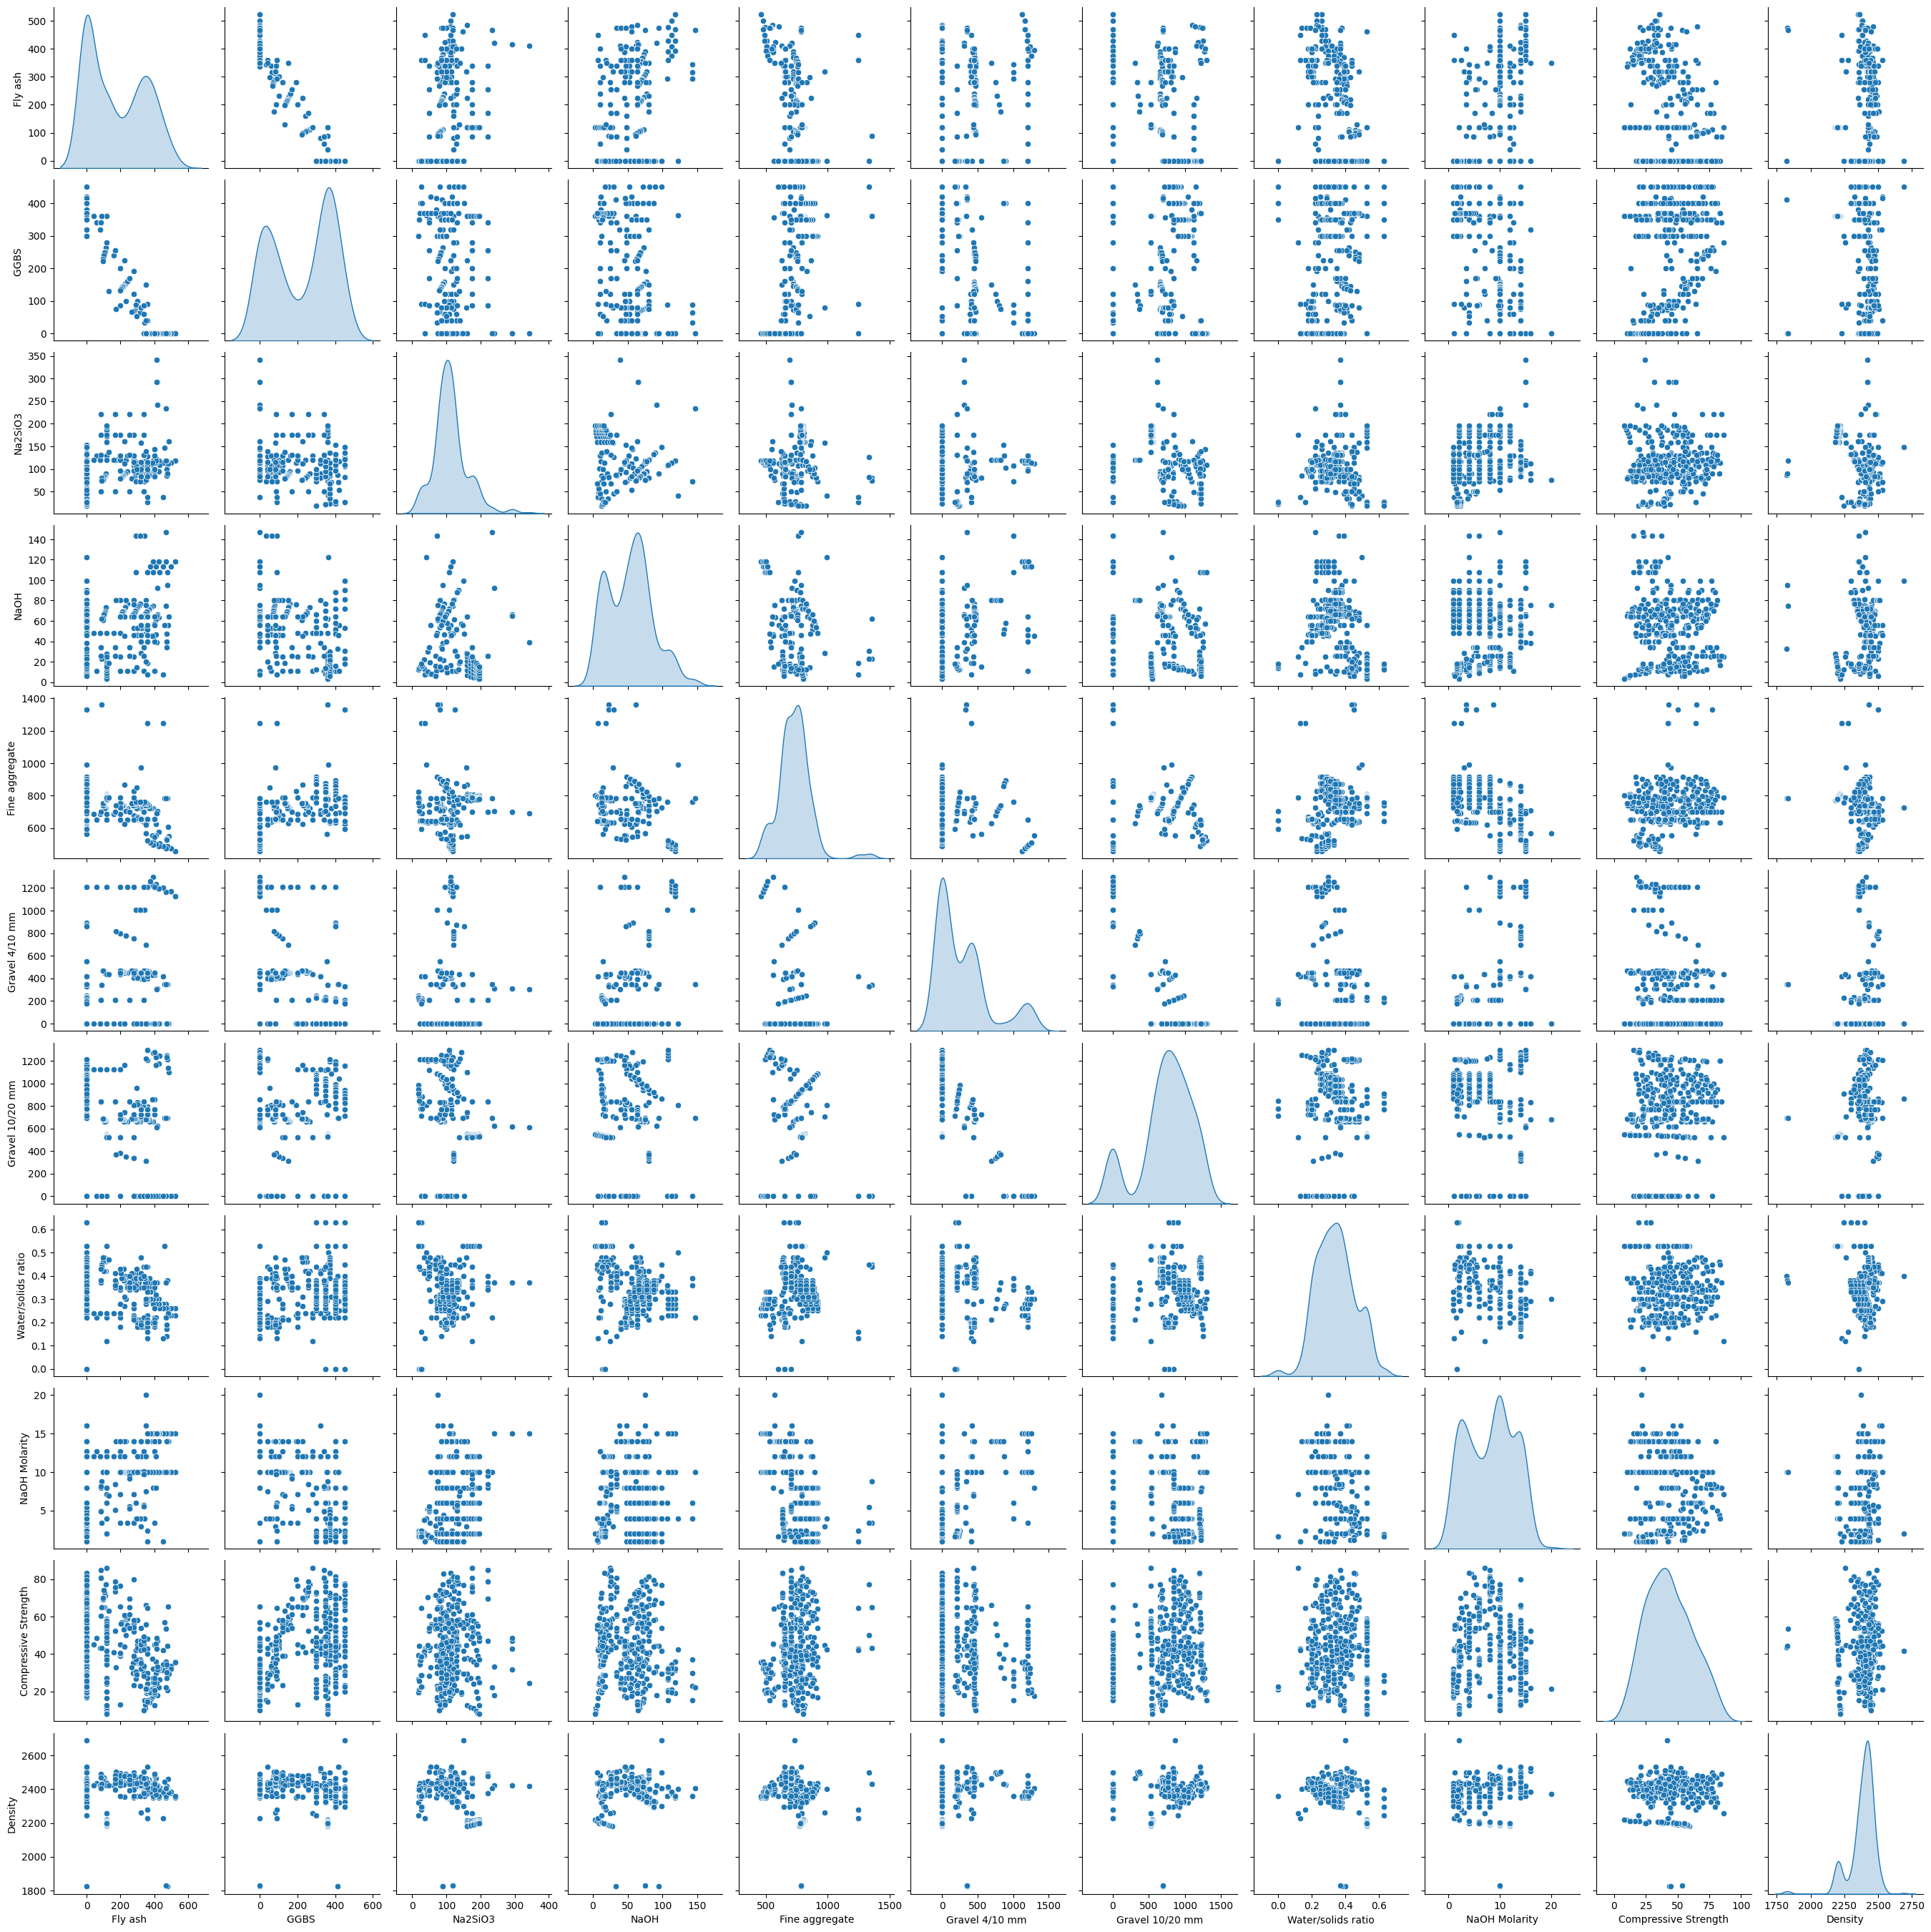

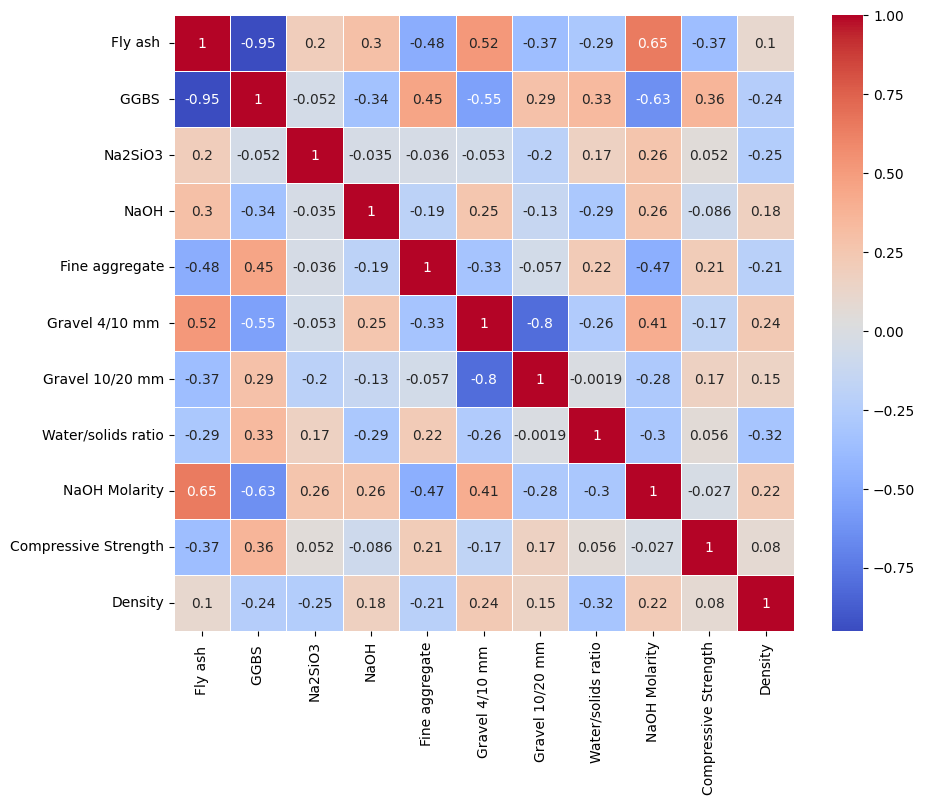

In [5]:
# Display histograms for each feature to understand distributions - Essential for selecting SVR KERNEL
FA_geoPC.hist(bins=15, figsize=(15, 10), layout=(4, 4))
plt.tight_layout()
plt.show()

# Generate a pair plot to visualize the relationship between features
sns.pairplot(FA_geoPC, diag_kind='kde')
plt.show()

# Calculate and plot the correlation matrix
correlation_matrix = FA_geoPC.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

# Section 2:
## Data Preprocessing

In [15]:
# X are the features, y is the regressor, predictor
X = FA_geoPC.drop('Compressive Strength', axis=1)
y = FA_geoPC['Compressive Strength']

# Checking the dataset, there are missing values in predictor column Compressive Strength - let's just delete the blank rows
FA_geoPC = FA_geoPC.dropna(subset=['Compressive Strength'])

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  #random_state for reproducibility

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Ensure that X_test is scaled using the same scaler

# Checking the dataset, Replace NaN values with zero in both train and test sets
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)


# Section 3:
## Training

In [16]:
# Training the model with RBF kernel
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

print('Distribution of train and test sets:')
print(X_train.shape, X_test.shape, y_train.shape, y.shape)

Distribution of train and test sets:
(290, 10) (73, 10) (290,) (363,)


# Section 4:
Model Evaluation [Train and Test Models]

What the Metrics Mean:
1. **Mean Absolute Error (MAE)**: The average of the absolute differences between the predictions and actual observations, providing a linear score without direction.
2. **Mean Absolute Percentage Error (MAPE)**: gives an easy-to-interpret percentage measure of the error in prediction. Helps understand the error in terms of a percentage of the actual values.
3. **Mean Squared Error (MSE)**: Similar to MAE but squares the differences; it's more sensitive to outliers as larger errors have disproportionately large impacts.
4. **Root Mean Squared Error (RMSE)**: a standard way to measure the error of a model particularly useful when large errors are particularly undesirable as it squares the errors before averaging, which gives higher weight to larger errors.
5. **Coefficient of Determination, R-squared (R²)**: Indicates the data points that fall perfectly on the regression line and describes the goodness of fit of the model to the data set. The predictor x accounts for none (if R^2 is 0) of the variation in y, 1 is 100%.
6. **Explained Variance Score (EVS)**: Measures the proportion to which a mathematical model accounts for the variation (dispersion) of a given dataset.

In [17]:
#TRAINING MODEL Evaluation Metrics

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

#Predicting the train set results
y_trainpred = svr_model.predict(X_train_scaled)

print('Sample Predictions from Train Set (First 10 items):', y_trainpred[:10])

mae = mean_absolute_error(y_train, y_trainpred)
mape = mean_absolute_percentage_error(y_train, y_trainpred)
mse = mean_squared_error(y_train, y_trainpred)
rmse = root_mean_squared_error(y_train, y_trainpred)
r2 = r2_score(y_train, y_trainpred)
variance_score = explained_variance_score(y_train, y_trainpred)

print('Train Metrics:')
print('Mean Absolute Error: %.2f'% mae)
print('Mean Absolute Percentage Error (MAPE): %.2f'% mape, "%")
print('Mean Squared Error: %.2f'% mse)
print('Root Mean Squared Error (RMSE): %.2f'% rmse)
print("R^2 Score: %.2f"% r2)
print("EVS:%.2f"% variance_score)

Sample Predictions from Train Set (First 10 items): [45.57841193 47.89444447 36.29058222 36.85915512 42.81202251 38.8164992
 40.09240381 34.94814394 46.21027206 37.11050678]
Train Metrics:
Mean Absolute Error: 11.51
Mean Absolute Percentage Error (MAPE): 36.70 %
Mean Squared Error: 201.61
Root Mean Squared Error (RMSE): 14.20
R^2 Score: 0.34
EVS:0.34


In [18]:
#TEST MODEL Evaluation Metrics

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Predicting the test set results
y_pred = svr_model.predict(X_test_scaled)
print('Sample Predictions from Test Set (First 10 items):', y_pred[:10])

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
variance_score = explained_variance_score(y_test, y_pred)

print('Test Metrics:')
print("Mean Absolute Error:%.2f"% mae)
print("Mean Absolute Percentage Error (MAPE): %.2f"% mape, "%")
print("Mean Squared Error: %.2f"% mse)
print("Root Mean Squared Error (RMSE): %.2f"% rmse)
print("R^2 Score: %.2f"%  r2)
print("EVS: %.2f"% variance_score)

Sample Predictions from Test Set (First 10 items): [50.439751   48.67398889 40.6098461  46.33360335 44.28527292 35.16467467
 39.40779267 44.71018436 49.29059801 38.52711136]
Test Metrics:
Mean Absolute Error:12.84
Mean Absolute Percentage Error (MAPE): 38.09 %
Mean Squared Error: 250.41
Root Mean Squared Error (RMSE): 15.82
R^2 Score: 0.32
EVS: 0.33


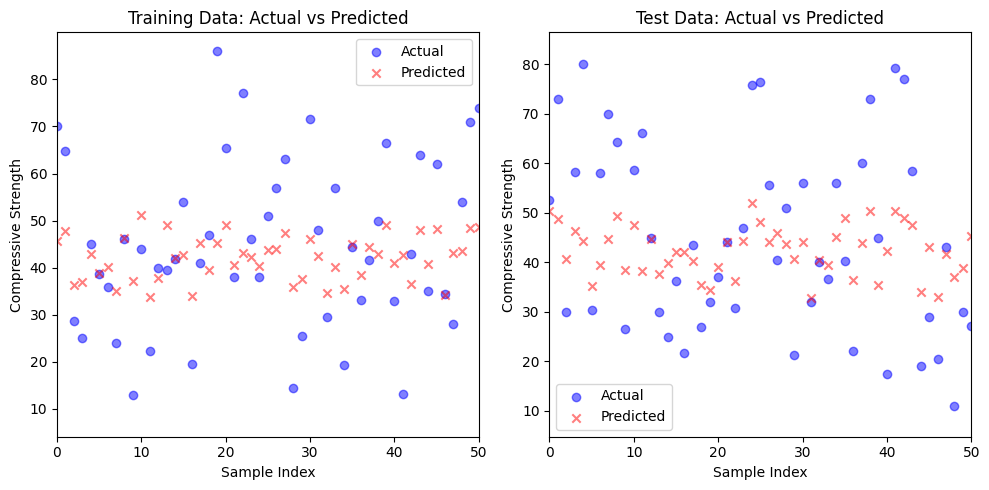

In [19]:
plt.rcParams['figure.figsize'] = [10, 5]  # Set figure size

# Plot for training data
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual', alpha=0.5, marker='o')
plt.scatter(range(len(y_trainpred)), y_trainpred, color='red', label='Predicted', alpha=0.5, marker='x')
plt.title('Training Data: Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Compressive Strength')
plt.legend()
plt.xlim(0, 50)  # Limiting the x-axis range to the first 50 samples


# Plot for testing data
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', alpha=0.5, marker='o')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.5, marker='x')
plt.title('Test Data: Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Compressive Strength')
plt.legend()
plt.xlim(0, 50)  # Limiting the x-axis range to the first 50 samples


plt.tight_layout()
plt.show()
